In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
counts = pd.read_csv("raw/pedestrian-counting-system-monthly-counts-per-hour.csv")
locations = pd.read_csv("raw/pedestrian-counting-system-sensor-locations.csv")

In [28]:
counts.head(5)

,ID,Location_ID,Sensing_Date,HourDay,Direction_1,Direction_2,Total_of_Directions,Sensor_Name,Location
0,47220260804,47,2026-08-04,2,6,18,24,Eli250_T,"-37.81258467, 144.9625775"
1,36320260804,36,2026-08-04,3,6,1,7,Que85_T,"-37.81652527, 144.96121062"
2,162020260804,162,2026-08-04,0,43,30,73,Eli489_T,"-37.80740397, 144.95987909"
3,29320260804,29,2026-08-04,3,0,2,2,AG_T,"-37.8199817, 144.96872865"
4,84020260804,84,2026-08-04,0,42,28,70,ElFi_T,"-37.81798049, 144.96503383"


In [30]:
counts["Location_ID"].nunique()

103

ID represent to a single record; <br><br>
Total_of_Directions is the total amount of people crossing through the sensor, it is repeatable (one person could walk through multiple times). In this senario, our Machine Learning model might consider it as noise level since the amount of people there could probably means the noise level;<br><br>
HourDay contain the time series in 24 hours;<br><br>
Locations record the geosite information we will use to navigete later on;<br><br>

In [29]:
locations.head(5)

,Location_ID,Sensor_Description,Sensor_Name,Installation_Date,Note,Location_Type,Status,Direction_1,Direction_2,Latitude,Longitude,Location
0,3,Melbourne Central,Swa295_T,2009-03-25,NaN,Outdoor,A,North,South,-37.811015,144.964295,"-37.81101524, 144.96429485"
1,5,Princes Bridge,PriNW_T,2009-03-26,Replace with: 00:6e:02:01:9e:54,Outdoor,A,North,South,-37.818742,144.967877,"-37.81874249, 144.96787656"
2,9,Southern Cross Station,Col700_T,2009-03-23,NaN,Outdoor,A,East,West,-37.819830,144.951026,"-37.81982992, 144.95102555"
3,11,Docklands Waterfront City Building Side,WatCit_T,2009-01-20,Device has been replaced with new sensor on 22...,Outdoor,A,East,West,-37.815667,144.939744,"-37.81566651, 144.93974366"
4,12,New Quay,NewQ_T,2009-01-21,NaN,Outdoor,A,East,West,-37.814580,144.942924,"-37.81457988, 144.94292398"


In [31]:
locations["Location_ID"].nunique()

134

There are 31 sensor do not have a record or be replaced, and if we want to make a route, perhaps, the indoor sensory should not be included, cause we have to assume that our route will not cross from a infrastracture such as a library or train station, its only along the roads.

So far there are two steps that the raw data needs to be done:<br><br>
1: remove the Indoor type sensor in the Location_Type column (locations)<br>
2: filter out the non-recording sensor by merging the primary key Location_ID and deleting the non-existing sensor (counts).<br>
The final data we need include those columnes: Location_ID(PK), Sensing_Date, HourDay, Total_of_Directions, Locations... 

Moving on to the abnormal data observation 

This project plan to use the latest one year record(01/08/2025 - 01/08/2026) as the train set, so here, trying to have a basic view of the dataset in case there is any abnormal data might increase the bias of the ML model.

In [5]:
counts["Sensing_Date"] = pd.to_datetime(counts["Sensing_Date"])

train_counts = counts[
    (counts["Sensing_Date"] >= "2025-08-01") &
    (counts["Sensing_Date"] <= "2026-08-01")
].copy()

train_counts.head()

,ID,Location_ID,Sensing_Date,HourDay,Direction_1,Direction_2,Total_of_Directions,Sensor_Name,Location
4736,501220260801,50,2026-08-01,12,412,352,764,Lyg309_T,"-37.79808192, 144.96721013"
4737,1351420260801,135,2026-08-01,14,368,477,845,Spen161_T,"-37.8172861, 144.95319102"
4738,1841020260801,184,2026-08-01,10,659,531,1190,Eli124_T,"-37.81512416, 144.96371988"
4739,1621020260801,162,2026-08-01,10,596,545,1141,Eli489_T,"-37.80740397, 144.95987909"
4740,72820260801,72,2026-08-01,8,61,30,91,ACMI_T,"-37.81726338, 144.96872809"


In [6]:
print(train_counts["Sensing_Date"].min())
print(train_counts["Sensing_Date"].max())
print(train_counts.shape)

2025-08-01 00:00:00
2026-08-01 00:00:00
(827329, 9)


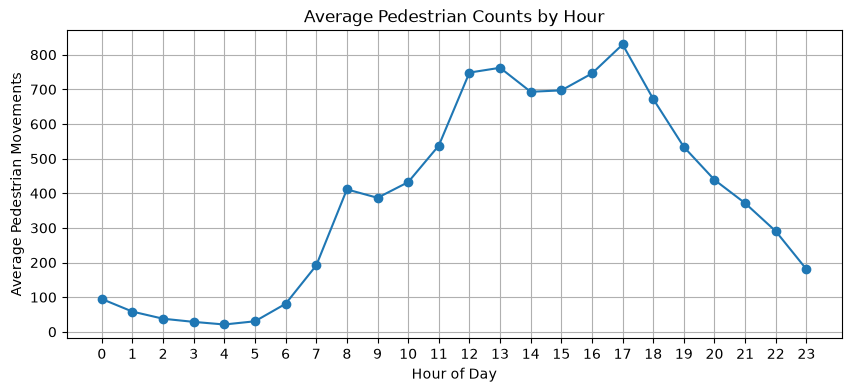

In [7]:
hourly_avg = train_counts.groupby("HourDay")["Total_of_Directions"].mean()

hourly_avg.plot(kind="line", marker="o", figsize=(10, 4))

plt.title("Average Pedestrian Counts by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Pedestrian Movements")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

Table above shows the total amount of pedestrain counts by hour, its seems reasonable, peak hour is about 5 pm after work. and attending work or school hour at 8, also the food hours 12-13. This chat did not split the weekend and weekday makes the afternoon activity a bit heavy, but still in a reasonable range.


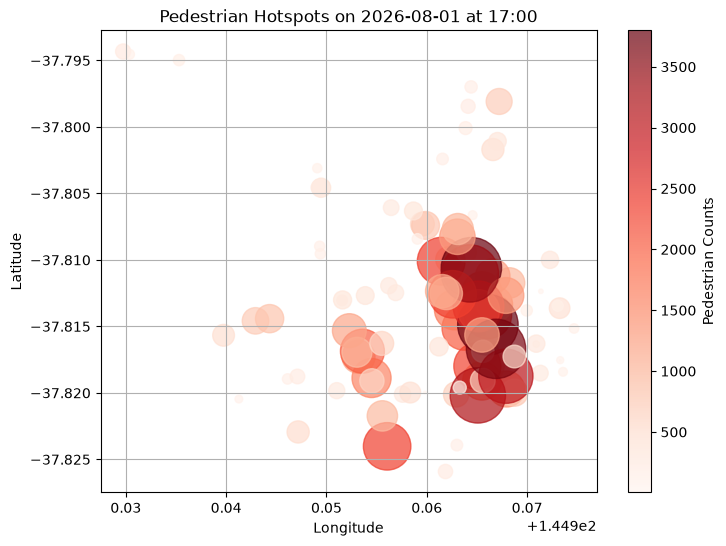

In [17]:
selected_date = "2026-08-01"
selected_hour = 17

one_time = train_counts[
    (train_counts["Sensing_Date"] == selected_date) &
    (train_counts["HourDay"] == selected_hour)
].copy()

one_time = one_time.merge(
    locations[["Location_ID", "Latitude", "Longitude"]],
    on="Location_ID",
    how="left"
)

plt.figure(figsize=(8, 6))

plt.scatter(
    one_time["Longitude"],
    one_time["Latitude"],
    s=one_time["Total_of_Directions"] * 0.5,
    c=one_time["Total_of_Directions"],
    cmap="Reds",
    alpha=0.7
)

plt.colorbar(label="Pedestrian Counts")
plt.title(f"Pedestrian Hotspots on {selected_date} at {selected_hour}:00")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

Met issues with using a real map to virtualize this single hour record in 01-08-2026, but manually search the most crowded place at that time are Town Hall, QV, Flinders La-Swanston and Melbourne Central. In the real geograph map, these locations match the strongest red circle in the hotspots. 

The ML database planed to remove the abnormal data coming from a special day such as a public holiday or an arranged parade. However, there are too much works to do with it, then this project will decide to keep those data here and use perhaps regularization method to reduce the effect from this bias.

One more addiction, only keeps the Melbourne CBD sensor will be enough

In summary<br><br>
Below are the data cleaning requirements:<br>
1. Only needs the data in Melbourne CBD area, please define the range of CBD area with references.<br>
2. Period between 01-08-2025 to 01-08-2026<br>
3. Only Outdoor sensors<br>
4. Add a new column called "WEEKEND"， if its weekday answer NO, if its weekend fill in YES<br>
5. Do not include any outdated sensor or not working sensor ('locations' still record those old sensor which are not used anymore)
6. Location_id, HourDay, Total_Of_Direction, Location, WEEKEND (those are the columns required for ML part, if there is anything missing, please direct add and leave notes.)

counts_Link: https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-sensor-locations/table/?dataChart=eyJxdWVyaWVzIjpbeyJjaGFydHMiOlt7InR5cGUiOiJjb2x1bW4iLCJmdW5jIjoiQ09VTlQiLCJ5QXhpcyI6InNlbnNvcl9pZCIsInNjaWVudGlmaWNEaXNwbGF5Ijp0cnVlLCJjb2xvciI6IiNFNTBFNTYifV0sInhBeGlzIjoiaW5zdGFsbGF0aW9uX2RhdGUiLCJtYXhwb2ludHMiOiIiLCJ0aW1lc2NhbGUiOiJ5ZWFyIiwic29ydCI6IiIsImNvbmZpZyI6eyJkYXRhc2V0IjoicGVkZXN0cmlhbi1jb3VudGluZy1zeXN0ZW0tc2Vuc29yLWxvY2F0aW9ucyIsIm9wdGlvbnMiOnt9fX1dLCJkaXNwbGF5TGVnZW5kIjp0cnVlLCJhbGlnbk1vbnRoIjp0cnVlfQ%3D%3D&location=14,-37.80592,144.95928&basemap=mbs-7a7333

locations_Link: https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-monthly-counts-per-hour/table/?sort=sensing_date